# Preprocessing & Modeling
## Random Forest Regression untuk Prediksi Penjualan UMKM

## Step 1: Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

print('✅ Semua library berhasil di-import')

✅ Semua library berhasil di-import


## Step 2: Load Data dari Notebook EDA

In [14]:
# Load dataset
data_path = '../data/raw/dummy_dataset.csv'
df = pd.read_csv(data_path)
print(f"✅ Data loaded: {df.shape}")
print(f"\n📝 Columns: {df.columns.tolist()}")
print(f"\n🔍 First 5 rows:")
print(df.head())

✅ Data loaded: (500, 4)

📝 Columns: ['tanggal', 'nama_produk', 'harga', 'jumlah']

🔍 First 5 rows:
      tanggal     nama_produk  harga  jumlah
0  2026-05-11            Oreo  13977      12
1  2026-05-08            Oreo  17248      21
2  2026-05-08  Keripik Pisang  15735      25
3  2026-05-08      Bolu Kukus  15973      25
4  2026-05-11      Bolu Kukus  17688      24


## Step 3: Handle Missing Values

In [15]:
df_preproc = df.copy()
target_col = 'jumlah' if 'jumlah' in df_preproc.columns else 'jumlah_terjual'

numeric_cols = df_preproc.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_preproc.select_dtypes(include=['object', 'category']).columns.tolist()

print("="*80)
print("📌 MISSING VALUES:")
print("="*80)

missing_counts = df_preproc.isnull().sum()
if missing_counts.sum() > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("✅ Tidak ada missing value")

# Fill numeric
for col in numeric_cols:
    if df_preproc[col].isnull().any():
        df_preproc[col].fillna(df_preproc[col].median(), inplace=True)

# Fill categorical
for col in categorical_cols:
    if df_preproc[col].isnull().any():
        df_preproc[col].fillna(df_preproc[col].mode()[0], inplace=True)

print("✅ Missing values handled")

📌 MISSING VALUES:
✅ Tidak ada missing value
✅ Missing values handled


## Step 4: Handle Outliers dengan IQR

In [16]:
df_out = df_preproc.copy()

print("="*80)
print("🔍 OUTLIER DETECTION & HANDLING:")
print("="*80)

for col in numeric_cols:
    if col == target_col:
        continue
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_out[(df_out[col] < lower_bound) | (df_out[col] > upper_bound)]
    print(f"  {col}: {len(outliers)} outliers, bounds=[{lower_bound:.2f}, {upper_bound:.2f}]")
    
    df_out[col] = np.where(df_out[col] < lower_bound, lower_bound,
                           np.where(df_out[col] > upper_bound, upper_bound, df_out[col]))

print("\n✅ Outliers handled")

🔍 OUTLIER DETECTION & HANDLING:
  harga: 0 outliers, bounds=[6451.25, 25893.25]

✅ Outliers handled


## Step 5: Categorical Encoding

In [17]:
df_encoded = df_out.copy()

print("="*80)
print("🔤 CATEGORICAL ENCODING:")
print("="*80)

categorical_cols_check = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols_check:
    df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_check, drop_first=True)
    print(f"✅ One-Hot Encoding untuk {len(categorical_cols_check)} kolom")
    for col in categorical_cols_check:
        print(f"   - {col}")
else:
    print("ℹ️ Tidak ada kolom kategorikal")

print(f"\n📊 Shape setelah encoding: {df_encoded.shape}")

🔤 CATEGORICAL ENCODING:
✅ One-Hot Encoding untuk 2 kolom
   - tanggal
   - nama_produk

📊 Shape setelah encoding: (500, 11)


## Step 6: Feature Scaling

In [18]:
numeric_cols_scaled = [col for col in df_encoded.select_dtypes(include=[np.number]).columns if col != target_col]

print("="*80)
print("📐 FEATURE SCALING - StandardScaler:")
print("="*80)

print("\n📊 STATISTIK SEBELUM SCALING:")
print(df_encoded[numeric_cols_scaled].describe().T[['mean', 'std', 'min', 'max']])

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_cols_scaled] = scaler.fit_transform(df_scaled[numeric_cols_scaled])

print("\n📊 STATISTIK SETELAH SCALING:")
print(df_scaled[numeric_cols_scaled].describe().T[['mean', 'std', 'min', 'max']])
print("\n✅ Feature scaling selesai")

📐 FEATURE SCALING - StandardScaler:

📊 STATISTIK SEBELUM SCALING:
            mean          std      min      max
harga  16172.592  2790.316186  11511.0  20954.0

📊 STATISTIK SETELAH SCALING:
               mean       std       min       max
harga -2.060574e-16  1.001002 -1.672305  1.715288

✅ Feature scaling selesai


## Step 7: Feature Selection

✨ FEATURE SELECTION:

📌 Korelasi fitur terhadap target:
jumlah                        1.000000
nama_produk_Oreo              0.098779
tanggal_2026-05-10            0.070782
nama_produk_Keripik Pisang    0.057975
tanggal_2026-05-11            0.042085
tanggal_2026-05-12            0.038352
tanggal_2026-05-13            0.038339
harga                         0.037951
tanggal_2026-05-08            0.034921
nama_produk_Kopi Bubuk        0.020088
tanggal_2026-05-09            0.004759
Name: jumlah, dtype: float64


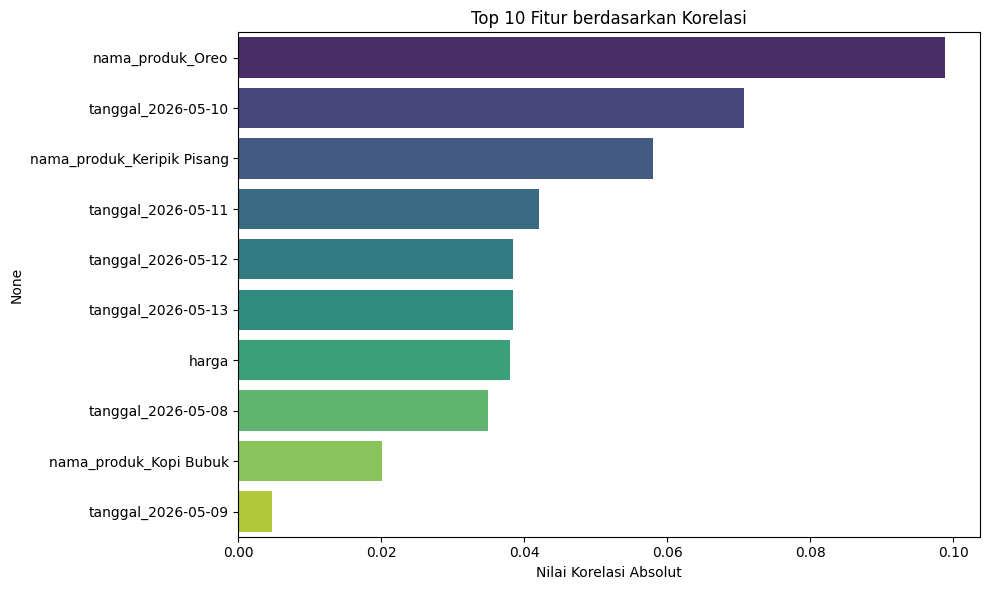


⚠️ Menggunakan top 3 fitur karena tidak ada korelasi >= 0.1

✅ 3 fitur terpilih
   - nama_produk_Oreo: korelasi = 0.0988
   - tanggal_2026-05-10: korelasi = 0.0708
   - nama_produk_Keripik Pisang: korelasi = 0.0580


In [19]:
print("="*80)
print("✨ FEATURE SELECTION:")
print("="*80)

corr_with_target = df_scaled.corr()[target_col].abs().sort_values(ascending=False)
print("\n📌 Korelasi fitur terhadap target:")
print(corr_with_target)

# Plot
plt.figure(figsize=(10, 6))
corr_plot = corr_with_target.drop(target_col).head(10)
sns.barplot(x=corr_plot.values, y=corr_plot.index, palette='viridis')
plt.title("Top 10 Fitur berdasarkan Korelasi")
plt.xlabel("Nilai Korelasi Absolut")
plt.tight_layout()
plt.show()

# Pilih fitur signifikan
threshold = 0.1
selected_features = corr_with_target[(corr_with_target >= threshold) & (corr_with_target.index != target_col)].index.tolist()

if not selected_features:
    selected_features = corr_with_target.drop(target_col).head(3).index.tolist()
    print(f"\n⚠️ Menggunakan top 3 fitur karena tidak ada korelasi >= {threshold}")

print(f"\n✅ {len(selected_features)} fitur terpilih")
for feat in selected_features:
    print(f"   - {feat}: korelasi = {corr_with_target[feat]:.4f}")

## Step 8: Train-Test Split

In [20]:
print("="*80)
print("📊 TRAIN-TEST SPLIT (80:20):")
print("="*80)

X = df_scaled[selected_features].copy()
y = df_scaled[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\n✅ Split configuration:")
print(f"   Total samples: {len(X)}")
print(f"   Training samples: {len(X_train)} (80%)")
print(f"   Testing samples: {len(X_test)} (20%)")
print(f"\n📊 Shape:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

📊 TRAIN-TEST SPLIT (80:20):

✅ Split configuration:
   Total samples: 500
   Training samples: 400 (80%)
   Testing samples: 100 (20%)

📊 Shape:
   X_train: (400, 3)
   X_test:  (100, 3)
   y_train: (400,)
   y_test:  (100,)


## Step 9: Training Random Forest

In [21]:
print("="*80)
print("🌳 TRAINING RANDOM FOREST REGRESSOR:")
print("="*80)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print(f"\n📋 Model configuration:")
print(f"   n_estimators: {rf_model.n_estimators}")
print(f"   max_depth: {rf_model.max_depth}")

print(f"\n🔧 Training dengan {len(X_train)} samples...")
rf_model.fit(X_train, y_train)
print("✅ Training completed!")

# Save model
model_path = '../model/rf_model.pkl'
Path(model_path).parent.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_model, model_path)
print(f"💾 Model saved to: {model_path}")

🌳 TRAINING RANDOM FOREST REGRESSOR:

📋 Model configuration:
   n_estimators: 100
   max_depth: 10

🔧 Training dengan 400 samples...
✅ Training completed!
💾 Model saved to: ../model/rf_model.pkl


## Step 10: Model Evaluation

In [22]:
print("="*80)
print("📊 MODEL EVALUATION & METRICS:")
print("="*80)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\n📈 PERFORMANCE METRICS:")
print(f"\n  TRAIN SET:")
print(f"    MAE:  {mae_train:.4f}")
print(f"    RMSE: {rmse_train:.4f}")
print(f"    R²:   {r2_train:.4f}")

print(f"\n  TEST SET:")
print(f"    MAE:  {mae_test:.4f}")
print(f"    RMSE: {rmse_test:.4f}")
print(f"    R²:   {r2_test:.4f}")

print(f"\n💡 INTERPRETASI:")
if r2_test > 0.7:
    print(f"    ✅ Model performance: BAIK (R² > 0.7)")
elif r2_test > 0.5:
    print(f"    🟡 Model performance: SEDANG (0.5 < R² < 0.7)")
else:
    print(f"    ⚠️ Model performance: PERLU IMPROVEMENT (R² < 0.5)")

📊 MODEL EVALUATION & METRICS:

📈 PERFORMANCE METRICS:

  TRAIN SET:
    MAE:  5.2236
    RMSE: 6.0452
    R²:   0.0241

  TEST SET:
    MAE:  5.6720
    RMSE: 6.4942
    R²:   -0.0312

💡 INTERPRETASI:
    ⚠️ Model performance: PERLU IMPROVEMENT (R² < 0.5)


## Step 11: Feature Importance

🔥 FEATURE IMPORTANCE:

📊 Top fitur berdasarkan importance:
  tanggal_2026-05-10   █████████████████ 0.3570
  nama_produk_Oreo     ████████████████ 0.3394
  nama_produk_Keripik Pisang ███████████████ 0.3036


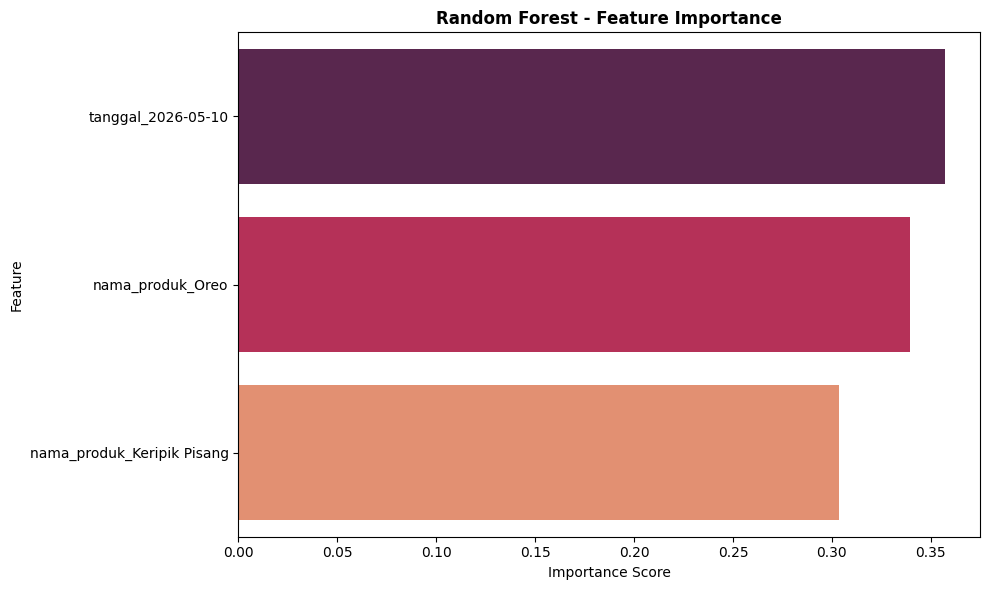

In [23]:
print("="*80)
print("🔥 FEATURE IMPORTANCE:")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top fitur berdasarkan importance:")
for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:20s} {bar} {row['importance']:.4f}")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='rocket')
plt.title("Random Forest - Feature Importance", fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Step 12: Visualisasi Prediksi vs Actual

📈 PREDICTION vs ACTUAL VISUALIZATION:


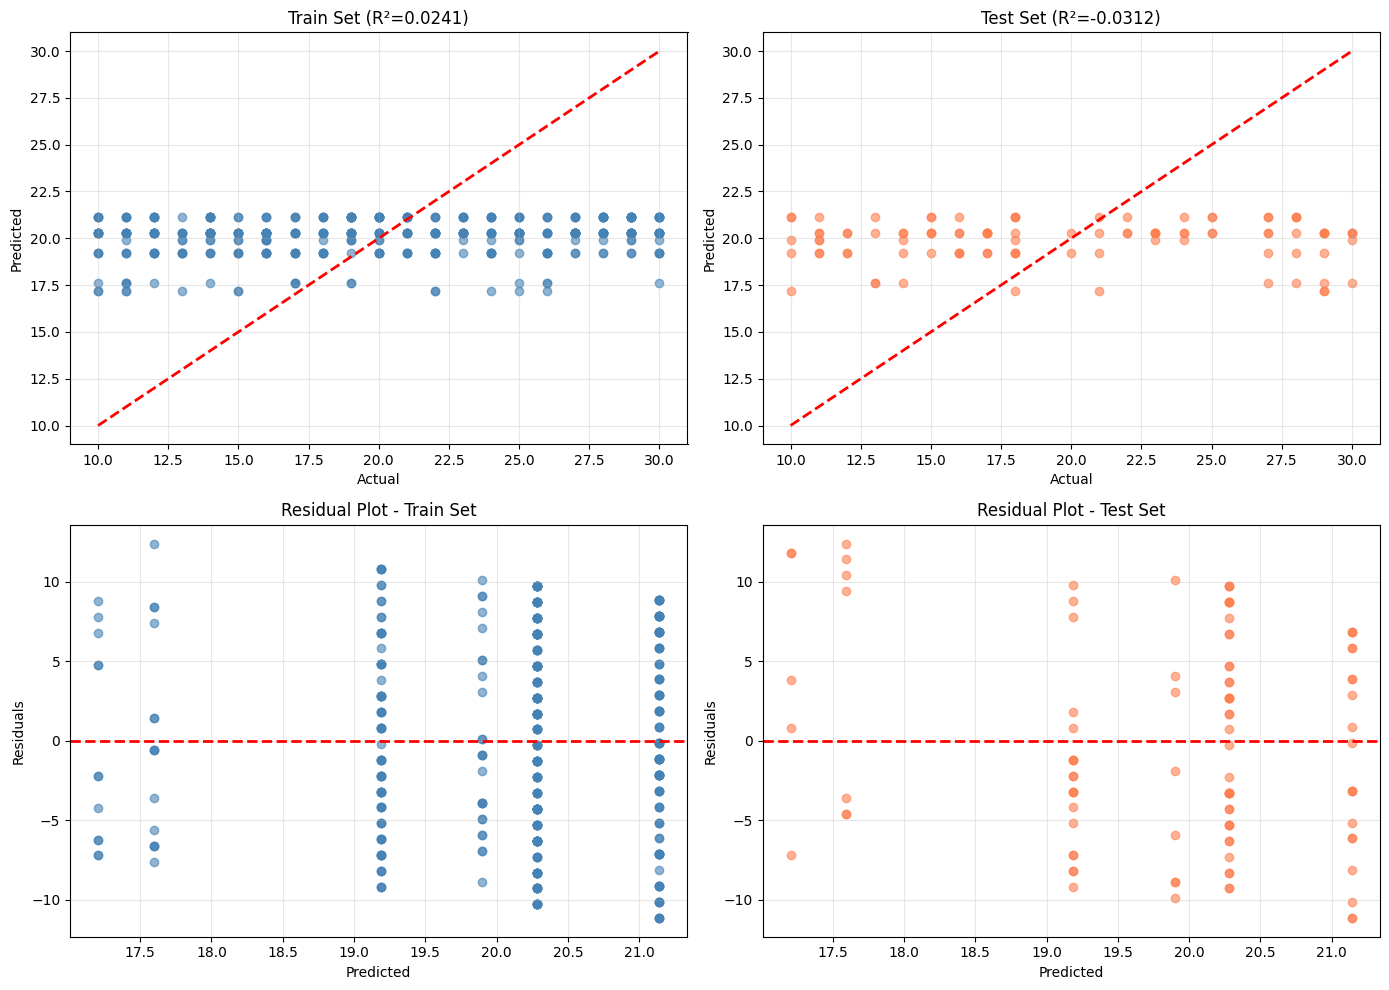


✅ Visualisasi selesai!


In [24]:
print("="*80)
print("📈 PREDICTION vs ACTUAL VISUALIZATION:")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot train
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6, color='steelblue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Train Set (R²={r2_train:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot test
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, color='coral')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Test Set (R²={r2_test:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Residual train
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.6, color='steelblue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot - Train Set')
axes[1, 0].grid(True, alpha=0.3)

# Residual test
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.6, color='coral')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual Plot - Test Set')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi selesai!")